In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, classification_report

# Load embeddings + labels
df = pd.read_csv("patient_embeddings_with_labels.csv")  # cruk_id + embeddings + shorter_dfs_balanced
df = df.dropna(subset=['shorter_dfs_balanced'])  # ensure target exists

# Features: all columns except cruk_id + target
feature_cols = [c for c in df.columns if c not in ['cruk_id', 'shorter_dfs_balanced']]
X = df[feature_cols].values.astype(np.float32)
y = df['shorter_dfs_balanced'].values.astype(int)

# Train/Val/Test split

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp
)

# Scale features
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Train logistic regression
clf = LogisticRegression(max_iter=1000, class_weight='balanced')  # handle imbalance
clf.fit(X_train, y_train)

# Evaluate model
def evaluate_model(clf, X, y, dataset_name="Dataset"):
    y_pred = clf.predict(X)
    y_prob = clf.predict_proba(X)[:, 1]
    acc = accuracy_score(y, y_pred)
    auc = roc_auc_score(y, y_prob)
    print(f"{dataset_name} Accuracy: {acc:.4f}, AUC: {auc:.4f}")
    print(confusion_matrix(y, y_pred))
    print(classification_report(y, y_pred))

evaluate_model(clf, X_train, y_train, "Train")
evaluate_model(clf, X_val, y_val, "Validation")
evaluate_model(clf, X_test, y_test, "Test")

Train Accuracy: 0.6414, AUC: 0.6781
[[74 45]
 [40 78]]
              precision    recall  f1-score   support

           0       0.65      0.62      0.64       119
           1       0.63      0.66      0.65       118

    accuracy                           0.64       237
   macro avg       0.64      0.64      0.64       237
weighted avg       0.64      0.64      0.64       237

Validation Accuracy: 0.6471, AUC: 0.5938
[[15 10]
 [ 8 18]]
              precision    recall  f1-score   support

           0       0.65      0.60      0.62        25
           1       0.64      0.69      0.67        26

    accuracy                           0.65        51
   macro avg       0.65      0.65      0.65        51
weighted avg       0.65      0.65      0.65        51

Test Accuracy: 0.3529, AUC: 0.3331
[[10 16]
 [17  8]]
              precision    recall  f1-score   support

           0       0.37      0.38      0.38        26
           1       0.33      0.32      0.33        25

    accuracy 

Test Accuracy: 0.5147, AUC: 0.5030


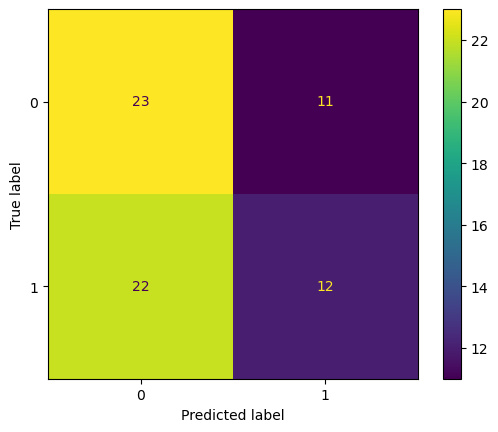

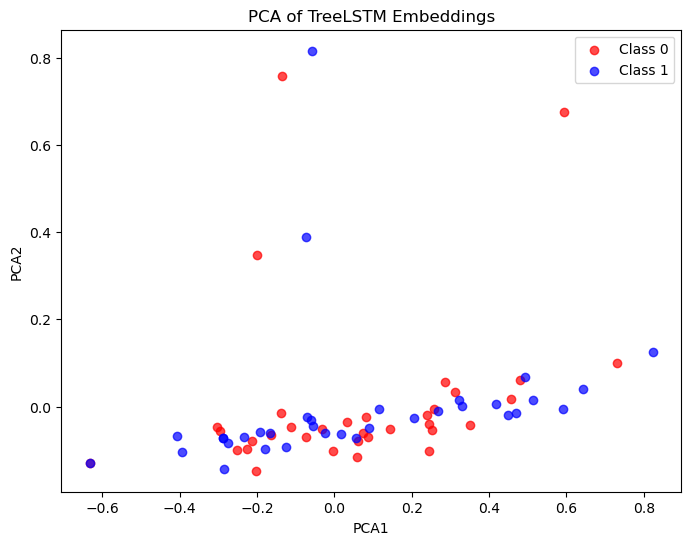

In [4]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

emb = pd.read_csv("patient_embeddings_with_labels.csv")
tx = pd.read_csv("data/tracerX.csv")
tx.columns = tx.columns.str.strip()

tx_keep = tx[['cruk_id', 'dfs_time', 'cens_dfs']].copy()
df_features = emb.merge(tx_keep, on='cruk_id', how='inner')
df_features = df_features.dropna(subset=['dfs_time', 'cens_dfs'])
df_features = df_features[df_features['dfs_time'] > 0]
# Create binary target for shorter DFS
X = df_features[[str(i) for i in range(32)]].values
y = df_features['shorter_dfs_balanced'].values # let's use 'shorter_dfs_balanced' as the target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Let's now consider PCA for dimensionality reduction (for visualization & regularization)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Logistic regression on PCA components
clf = LogisticRegression(penalty='l2', C=0.1, max_iter=1000)
clf.fit(X_train_pca, y_train)

# Predictions
y_pred = clf.predict(X_test_pca)
y_proba = clf.predict_proba(X_test_pca)[:,1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
print(f"Test Accuracy: {acc:.4f}, AUC: {auc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

# Visualize PCA components
plt.figure(figsize=(8,6))
for label, color in zip([0,1], ['red', 'blue']):
    idx = y_test == label
    plt.scatter(X_test_pca[idx,0], X_test_pca[idx,1], c=color, label=f'Class {label}', alpha=0.7)
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('PCA of TreeLSTM Embeddings')
plt.legend()
plt.show()

Test Accuracy: 0.5147, AUC: 0.5013


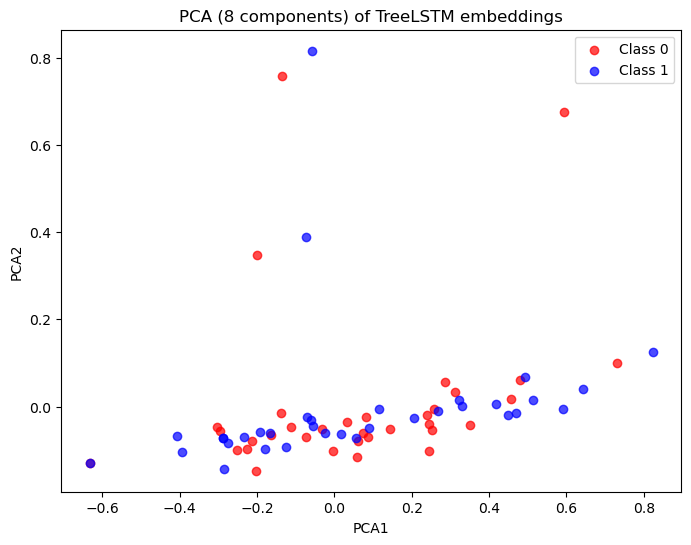

In [5]:
# Use more PCA components for modeling (not just 2)
n_components = 8  # or try 16
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Logistic regression on PCA-reduced data
clf = LogisticRegression(penalty='l2', C=0.1, max_iter=1000)
clf.fit(X_train_pca, y_train)

# Predictions
y_pred = clf.predict(X_test_pca)
y_proba = clf.predict_proba(X_test_pca)[:,1]

# Metrics
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
print(f"Test Accuracy: {acc:.4f}, AUC: {auc:.4f}")

plt.figure(figsize=(8,6))
for label, color in zip([0,1], ['red','blue']):
    idx = y_test == label
    plt.scatter(X_test_pca[idx,0], X_test_pca[idx,1], c=color, label=f'Class {label}', alpha=0.7)
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title(f'PCA ({n_components} components) of TreeLSTM embeddings')
plt.legend()
plt.show()